# Feature PDM

## 3D

### Imports

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from ppvm_py.utils import load_object

from ppvm_py.plotting import plot_timeseries
from ppvm_py.plotting import plot_heatmap
from ppvm_py.plotting import generate_2d_video

from ppvm_py.data_processing.patt_fld8v import print_xyz_slice_example_from_parsed_data

from ppvm_py.data_processing.utils import create_index_to_coord_map

from ppvm_py.feature_generation.sdc import compute_symmetric_difference_coefficients_with_index_to_coord_map

from ppvm_py.data_utils_3d import find_closest_coordinate_index

### General Args

In [2]:
# IMPORTANT: Restart Kernel when swapping datasets to reload them!
Ha = 300

if Ha == 300:
    patt_fld8v_folder_path = Path("../../../data/4pi_re1000_ha300.360_ch28.p1/patt_fld8v/")
elif Ha == 1000:
    patt_fld8v_folder_path = Path("../../../data/4pi_re1000_ha1000.384.pi/patt_fld8v/")

fld_path = patt_fld8v_folder_path / Path("pkl/patt_fld8v.pkl")

# Estimates from evaluations
sigma = -1  # According to the results here.
B_z = -1  # According to the results here.

animation_folder = Path(f"../output/animations/feature_pdm/")

truncate_data = False
truncate_at_snapshot = 20  # Including indices 0 to (truncate_at_snapshot - 1)

test_size = 0.3

input_window_shape = (1, 1, 3, 1)  # n_idx of (time, x, y, z) including center index.

##### Define output_indices

In [3]:
# SELECT ONE:
# 1: (1.5, 0, 0)
# 2: (8, 0, 0)
# ...
# (x, y, z) in [0, 12.56637] x [-1, 1] x [-1, 1]
location = 1

# When closest coordinates are not determined yet.
# Note: if 'True' is set for the first time, kernel must be restarted.
find_closest_coordinates = False

In [4]:
if location == 1:
    x_coord_desired = 1.5
    y_coord_desired = 0
    z_coord_desired = 0
    # closest available grid locations for desired ones have to be determined further below after data loading

    # Adjust according to error message. No error will be thrown after correct declaration.
    if Ha == 300:
        x_coord = 1.489348
        y_coord = 3.161188e-17
        z_coord = 3.161188e-17
        i_x = 64
        i_y = 45
        i_z = 45
    elif Ha == 1000:
        x_coord = np.nan
        y_coord = np.nan
        z_coord = np.nan
        i_x = np.nan
        i_y = np.nan
        i_z = np.nan

elif location == 2:
    x_coord_desired = 8
    y_coord_desired = 0
    z_coord_desired = 0

    # Adjust according to error message. No error will be thrown after correct declaration.
    if Ha == 300:
        x_coord = 8.005244
        y_coord = 3.161188e-17
        z_coord = 3.161188e-17
        i_x = 344
        i_y = 45
        i_z = 45
    elif Ha == 1000:
        x_coord = np.nan
        y_coord = np.nan
        z_coord = np.nan
        i_x = np.nan
        i_y = np.nan
        i_z = np.nan

temporal_border_margin = 2
output_indices = (
    slice(temporal_border_margin, -temporal_border_margin),
    slice(i_x, i_x + 1),
    slice(i_y, i_y + 1),
    slice(i_z, i_z + 1),
)

### Preamble

In [5]:
mean_mse = {}  # Dict for gathering mean-squared-errors.

n_window_indices = int(np.prod(list(input_window_shape)))

### Load Data

In [6]:
fld_data = load_object(fld_path)
if truncate_data:
    fld_data['timeseries'] = fld_data['timeseries'][:truncate_at_snapshot]
fld_data['index_to_coord_map'] = create_index_to_coord_map(fld_data['coord_to_index_map'])
print_xyz_slice_example_from_parsed_data(fld_data)

N, n_x, n_y, n_z, n_v = fld_data['timeseries'].shape  # N = num snapshots

Object successfully loaded from C:\Users\hydro\Documents\phd\nuclear_fusion_cooling\data\4pi_re1000_ha300.360_ch28.p1\patt_fld8v\pkl\patt_fld8v.pkl
The 3D data looks as follows:
N (number of snapshots) = 100
n_x (grid depth) = 541, n_y (grid height) = 91, n_z (grid width) = 91, n_v (number of variables) = 8
Labels:
['vx', 'vy', 'vz', 'jx', 'jy', 'jz', 'P', 'F']
Preview of the first snapshot (first 2 x, first 2 y, first 2 z) with coordinates:
  (x=0.00, y=-1.00, z=-1.00): [ 0.000000e+00  0.000000e+00  0.000000e+00 -1.464999e-19  0.000000e+00
  0.000000e+00 -4.031829e-04  1.353023e+00]
  (x=0.00, y=-1.00, z=-0.99): [ 0.000000e+00  0.000000e+00  0.000000e+00  3.428746e-20  0.000000e+00
 -1.176754e-02 -4.036609e-04  1.353055e+00]
  (x=0.00, y=-0.99, z=-1.00): [ 0.000000e+00  0.000000e+00  0.000000e+00 -4.206331e-19 -4.652879e-03
  0.000000e+00 -4.037547e-04  1.353035e+00]
  (x=0.00, y=-0.99, z=-0.99): [ 0.000000e+00  0.000000e+00  0.000000e+00 -1.286717e-21 -4.781152e-03
 -1.184628e-02 -4.

### Get Existing x, y and z Coordinates

In [7]:
# Fot initial determination of closest coordinates.
if find_closest_coordinates:
    x_coord = x_coord_desired
    y_coord = y_coord_desired
    z_coord = z_coord_desired
i_x, i_y, i_z = find_closest_coordinate_index(
    fld_data['coord_to_index_map'],
    x_coord=x_coord,
    y_coord=y_coord,
    z_coord=z_coord,
)

### Get $v_x$

In [8]:
v_x_3d = fld_data['timeseries'][
    :,
    i_x,
    i_y,
    i_z,
    fld_data['labels'].index('vx'),
]

## 2D

In [9]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from ppvm_py.utils import load_object

from ppvm_py.yz_slice_utils import find_closest_coordinate_index

from ppvm_py.plotting import plot_timeseries

from ppvm_py.data_processing.yz_slice import print_yz_slice_example_from_parsed_data
from ppvm_py.data_processing.utils import create_index_to_coord_map

from ppvm_py.feature_generation.sdc import symmetric_difference_coefficient
from ppvm_py.feature_generation.pdm import pdm_approximated_velocity

### General Args

In [10]:
random_state = 4629837

# IMPORTANT: Restart Kernel when swapping datasets to reload them!
Ha = 300

if Ha == 300:
    slice_folder_path = Path("../../../data/4pi_re1000_ha300.360_ch28.p1/SliceYZ_x0015/")
elif Ha == 1000:
    slice_folder_path = Path("../../../data/4pi_re1000_ha1000.384.pi/SliceYZ_x0015/")

# Estimates in determining_sigma_and_magnetic_field_strength.ipynb
sigma = -1
B_z = -1

test_size = 0.3

### Preamble

In [11]:
mses = {}  # Dict for gathering mean-squared-errors.

### Load Data

In [12]:
fld_path = slice_folder_path / Path("pkl/sliceYZ_x0015_fld.pkl")
gradF_path = slice_folder_path / Path("pkl/sliceYZ_x0015_gradF.pkl")

In [13]:
fld_data = load_object(fld_path)
fld_data['index_to_coord_map'] = create_index_to_coord_map(fld_data['coord_to_index_map'])
print_yz_slice_example_from_parsed_data(fld_data)
print()

if 'gradF_data' not in locals():
    gradF_data = load_object(gradF_path)
gradF_data['index_to_coord_map'] = create_index_to_coord_map(gradF_data['coord_to_index_map'])
print_yz_slice_example_from_parsed_data(gradF_data)

Object successfully loaded from C:\Users\hydro\Documents\phd\nuclear_fusion_cooling\data\4pi_re1000_ha300.360_ch28.p1\SliceYZ_x0015\pkl\sliceYZ_x0015_fld.pkl
The data looks as follows:
N (number of snapshots) = 20000
n_y (grid height) = 46, n_z (grid width) = 46, n_v (number of variables) = 8
Labels:
['vx', 'vy', 'vz', 'jx', 'jy', 'jz', 'P', 'F']
Preview of the first snapshot (first 2 y, first 2 z) with coordinates:
  (y=-1.00, z=-1.00): [ 0.000000e+00  0.000000e+00  0.000000e+00 -2.027423e-01  0.000000e+00
  0.000000e+00 -5.862112e-04  1.594463e+00]
  (y=-1.00, z=-0.99): [ 0.000000e+00  0.000000e+00  0.000000e+00 -2.175437e-01  0.000000e+00
 -4.764620e-01 -5.860972e-04  1.599692e+00]
  (y=-0.99, z=-1.00): [ 0.000000e+00  0.000000e+00  0.000000e+00 -1.220912e-01  2.072063e+00
  0.000000e+00 -5.841985e-04  1.580085e+00]
  (y=-0.99, z=-0.99): [ 2.256158e+00 -1.132797e-01  1.513446e-02 -2.226841e-01 -5.704941e-02
 -3.949543e-01 -5.842091e-04  1.584242e+00]

Object successfully loaded from

### Get Existing x and y Coordinates

In [14]:
y_coord_desired = 0
z_coord_desired = 0

# Adjust according to error message. No error will be thrown after correct adjustment.
# y_coord = y_coord_desired
# z_coord = z_coord_desired
if Ha == 300:
    y_coord = -0.01842125
    z_coord = -0.01842125
elif Ha == 1000:
    y_coord = 0
    z_coord = 0

i_y_center, i_z_center = find_closest_coordinate_index(
    fld_data['coord_to_index_map'],
    y_coord=y_coord,
    z_coord=z_coord,
)

### Plot $v_x$

In [15]:
v_x_2d = fld_data['timeseries'][
    :,
    i_y_center,
    i_z_center,
    fld_data['labels'].index('vx'),
]

## Comparison

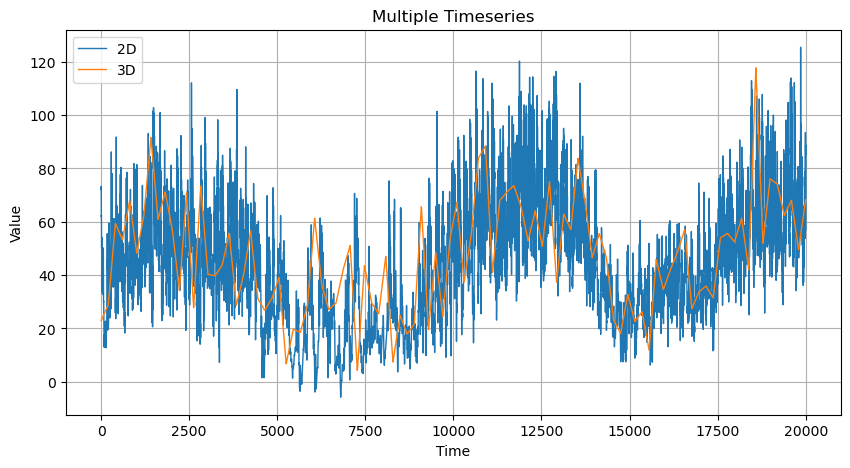

In [18]:
# original “time” for 3D: 0…99
t_short = np.linspace(0, len(v_x_2d)-1, len(v_x_3d))
# target time for both: 0…19999
t_long  = np.arange(len(v_x_2d))
# linear interpolation
v_x_3d_interp = np.interp(t_long, t_short, v_x_3d)

plot_timeseries(
    [
        v_x_2d,
        v_x_3d_interp,
    ],
    labels=[
        "2D",
        "3D",
    ],
)